In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn as sk

In [18]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "./datasets/titanic.csv"

df = pd.concat(
    [
        pd.read_csv(
            "./datasets/titanic/train.csv"
        ),
        pd.read_csv(
            "./datasets/titanic/test.csv"
        ),
    ]
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
df.shape

(1309, 12)

In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [21]:
from typing import Iterable

In [22]:
from pprint import pprint
pprint(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


### Добавление шума

In [23]:
def make_noise(df:pd.DataFrame, columns:Iterable, intensity:float = 0.1):
    length = len(df)
    for column in columns:
        try:
            ser = df[column]
            variance = ser.var()
            threshold = intensity * variance
            random_vector = np.random.uniform(-threshold, threshold, length)
            ser += random_vector
            df[column] = ser
        except Exception as e:
            print(e)
    return df

## Feature engineering

In [24]:
feature_columns = [col for col in df.columns if col not in ("PassengerId", 'Survived')]

In [26]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

df['Deck'] = df['Cabin'].str[0]

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/var/folders/8g/hrr0dtn57lb04xhx37szq0k00000gn/T/ipykernel_88464/1678132641.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [27]:
df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer', 'Dona'], dtype=object)

## Работа с выбросами и пропусками

In [28]:
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
FamilySize        0
IsAlone           0
AgeGroup        263
Deck           1014
Title             0
dtype: int64

In [29]:
df_useless = df[df.Survived.isna()]
df1 = df[~df.Survived.isna()]

In [30]:
df1.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
IsAlone          0
AgeGroup       177
Deck           687
Title            0
dtype: int64

In [32]:
df1['Age'].fillna(df1['Age'].mean(), inplace=True)

categorical_cols = ["Cabin", "Embarked", "AgeGroup", "Deck"]

for col in categorical_cols:
    if col in df1.columns:
        mode_val = df1[col].mode()
        if not mode_val.empty:
            df1[col].fillna(mode_val.iloc[0], inplace=True)

/var/folders/8g/hrr0dtn57lb04xhx37szq0k00000gn/T/ipykernel_88464/1478733248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Age'].fillna(df1['Age'].mean(), inplace=True)
/var/folders/8g/hrr0dtn57lb04xhx37szq0k00000gn/T/ipykernel_88464/1478733248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Age'].fillna(df1['Age'].mean(), i

In [33]:
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
IsAlone        0
AgeGroup       0
Deck           0
Title          0
dtype: int64

In [37]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup,Deck,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,2,0,Adult,C,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Middle,C,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1,1,Adult,C,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Adult,C,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,1,1,Adult,C,Mr


In [39]:
numeric_cols = ["Age", "FamilySize", "Fare"]
df1[numeric_cols].corr()

,Age,FamilySize,Fare
Age,1.000000,-0.248512,0.091566
FamilySize,-0.248512,1.000000,0.217138
Fare,0.091566,0.217138,1.000000


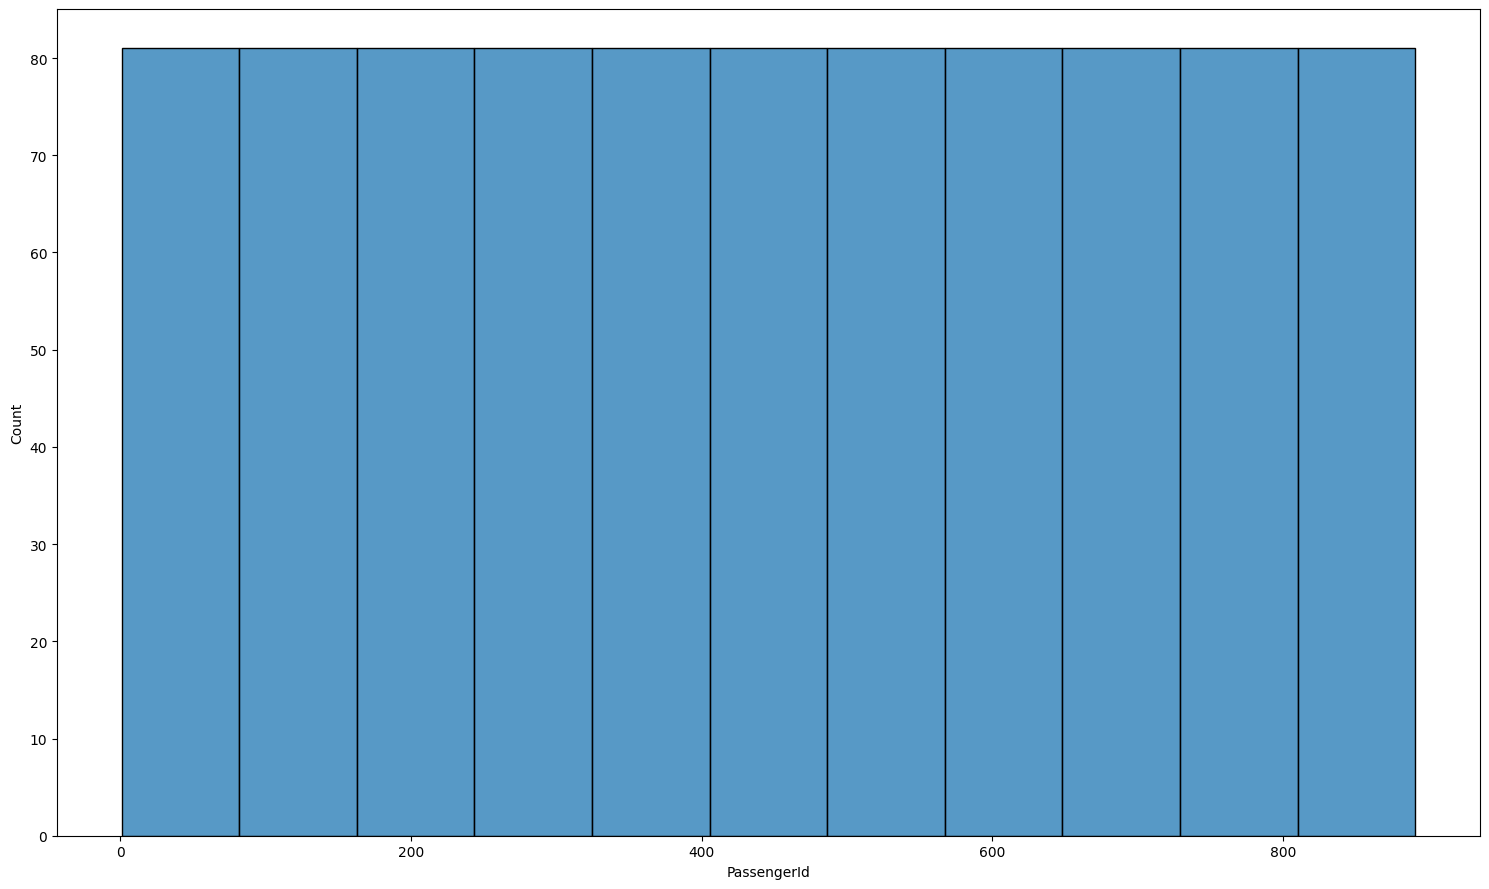

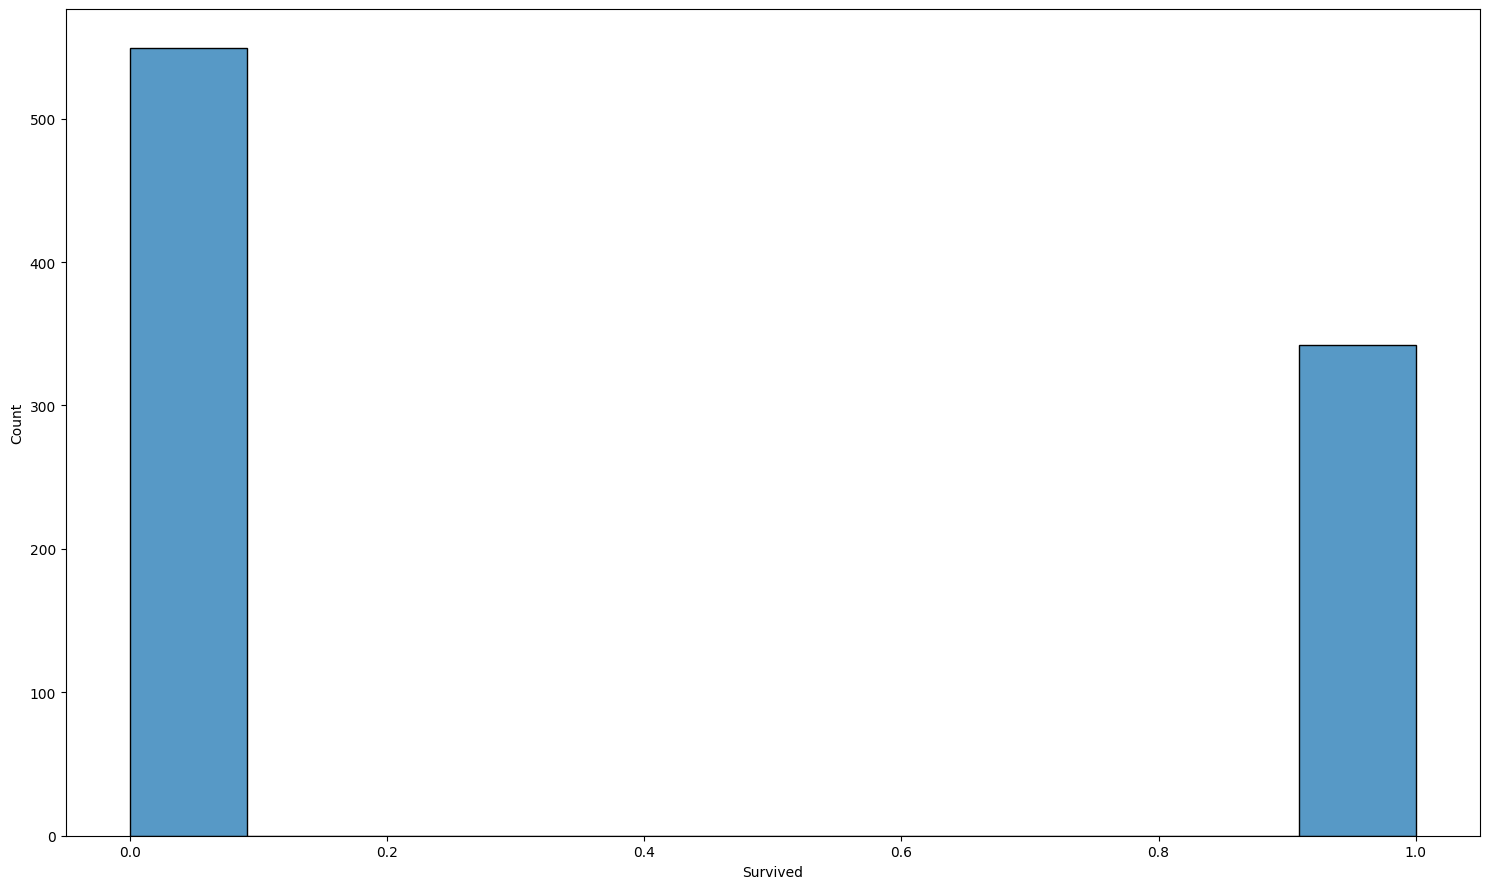

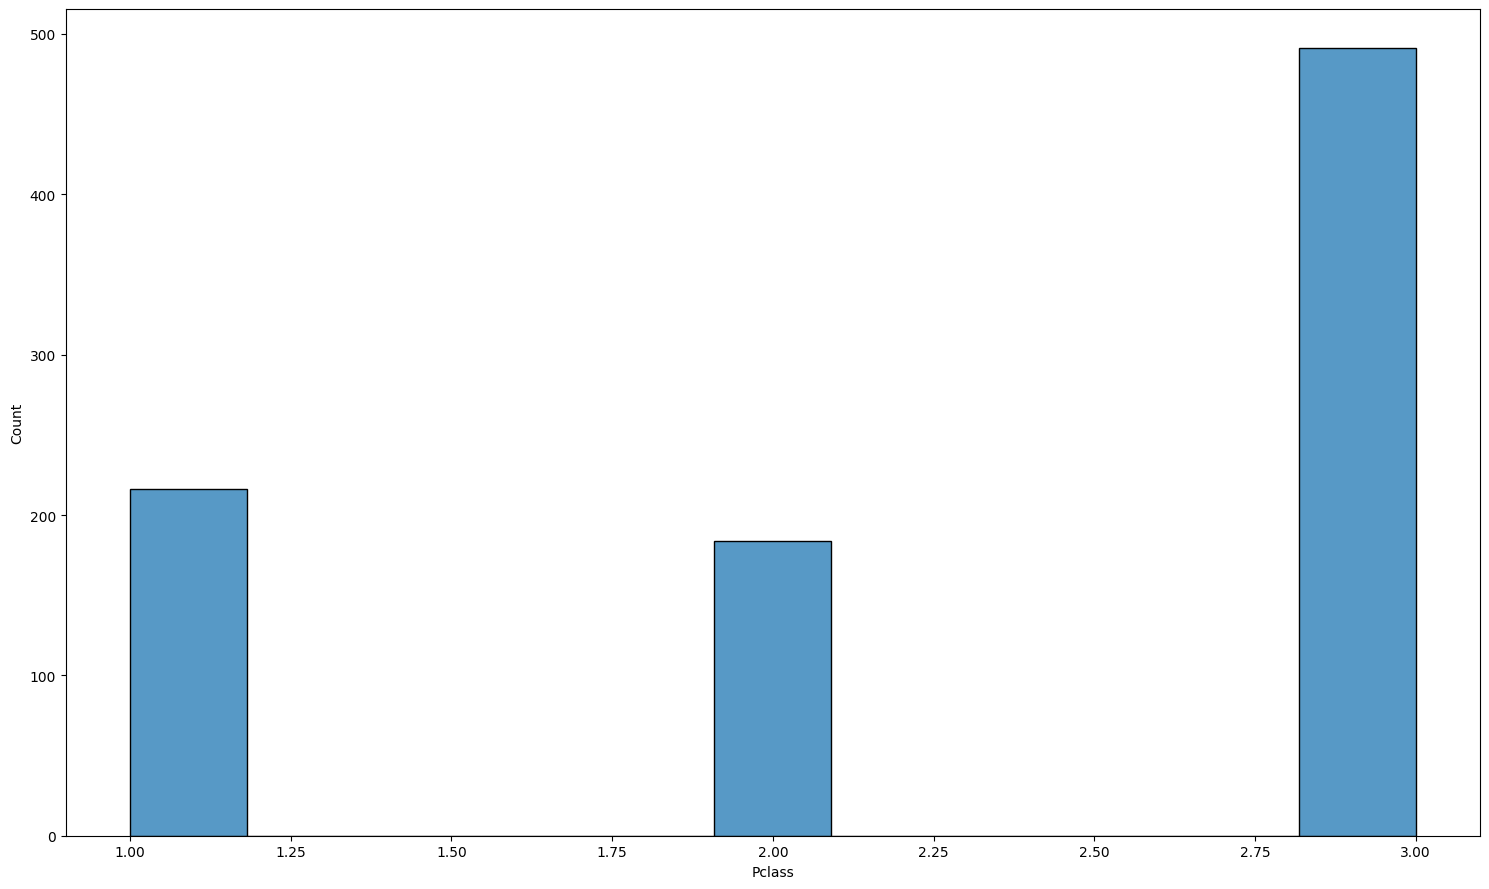

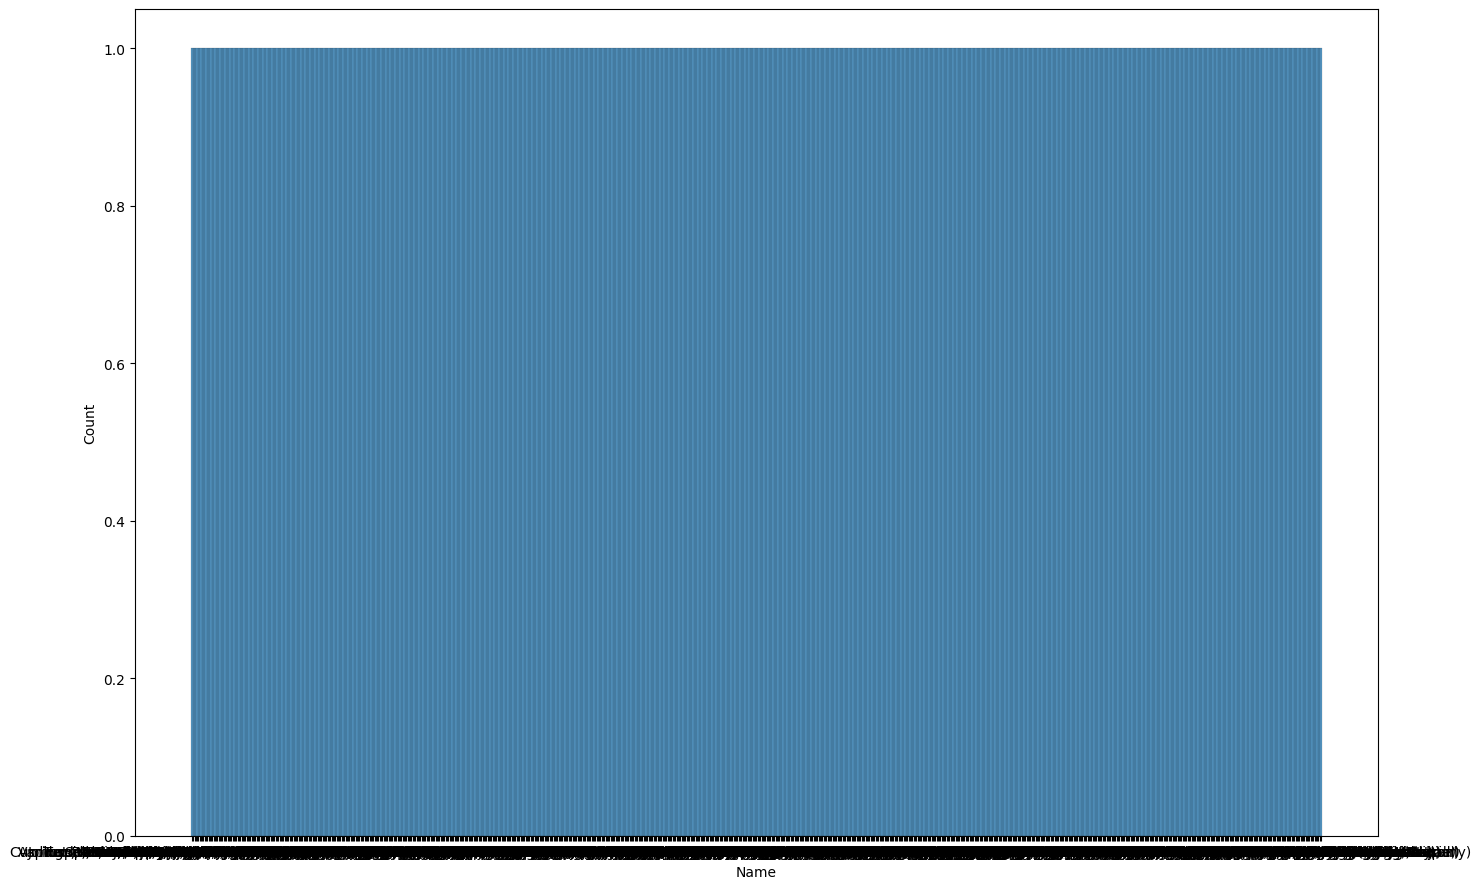

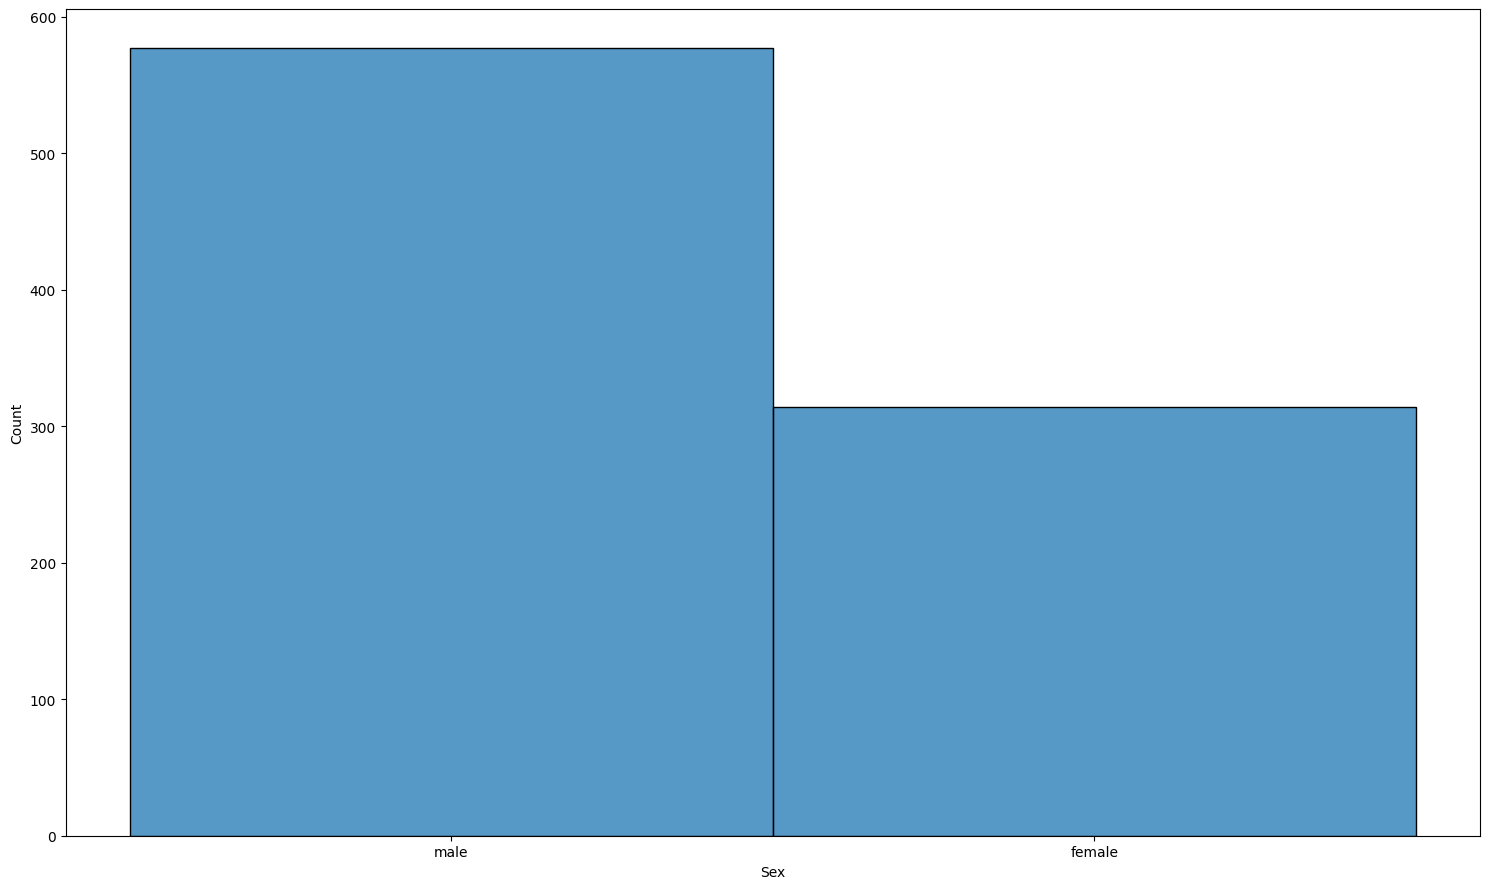

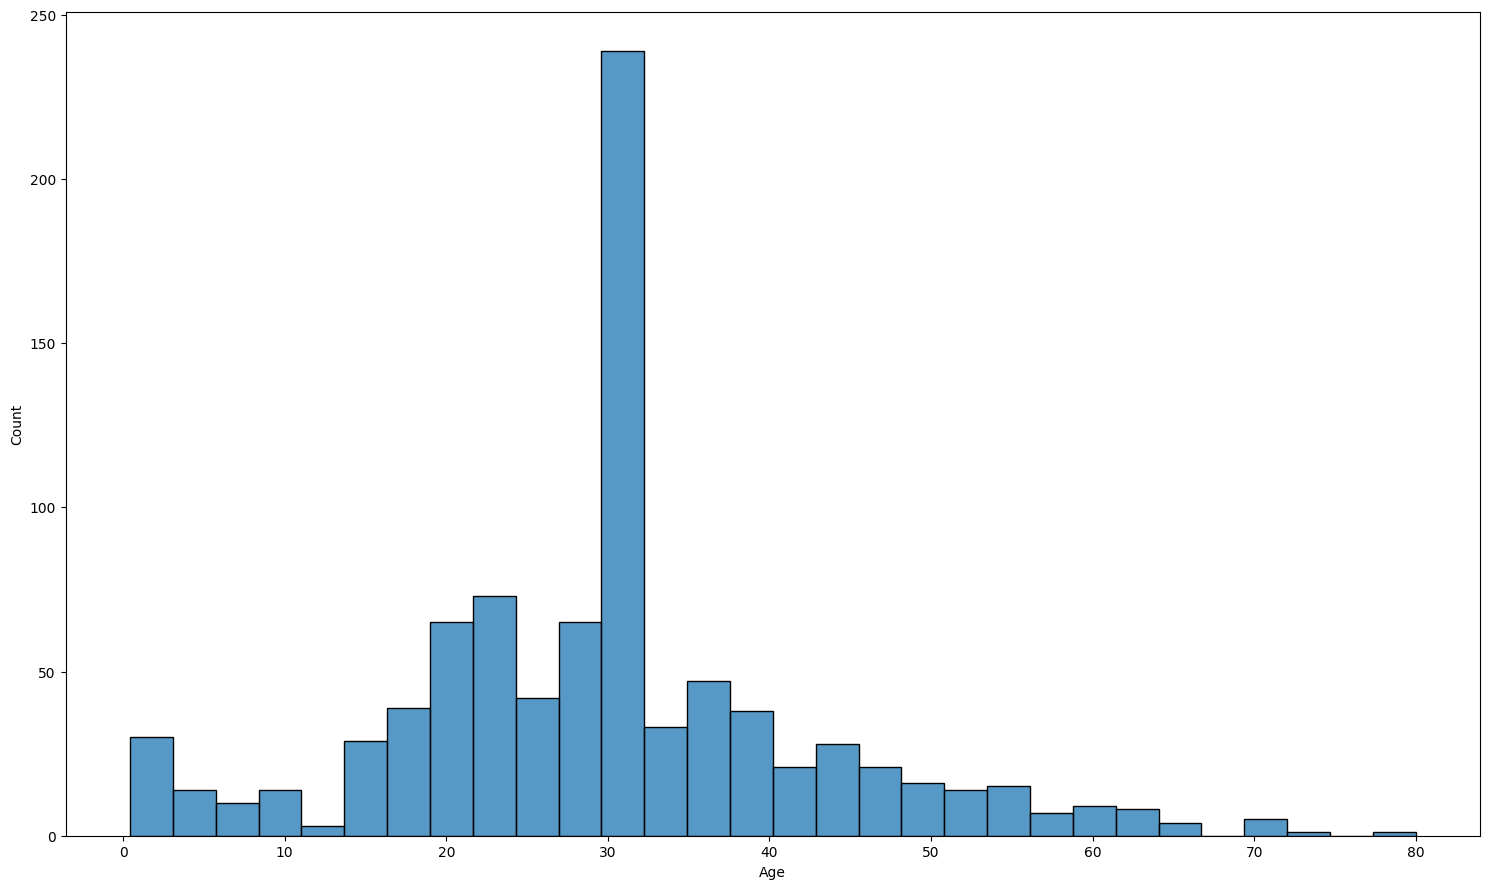

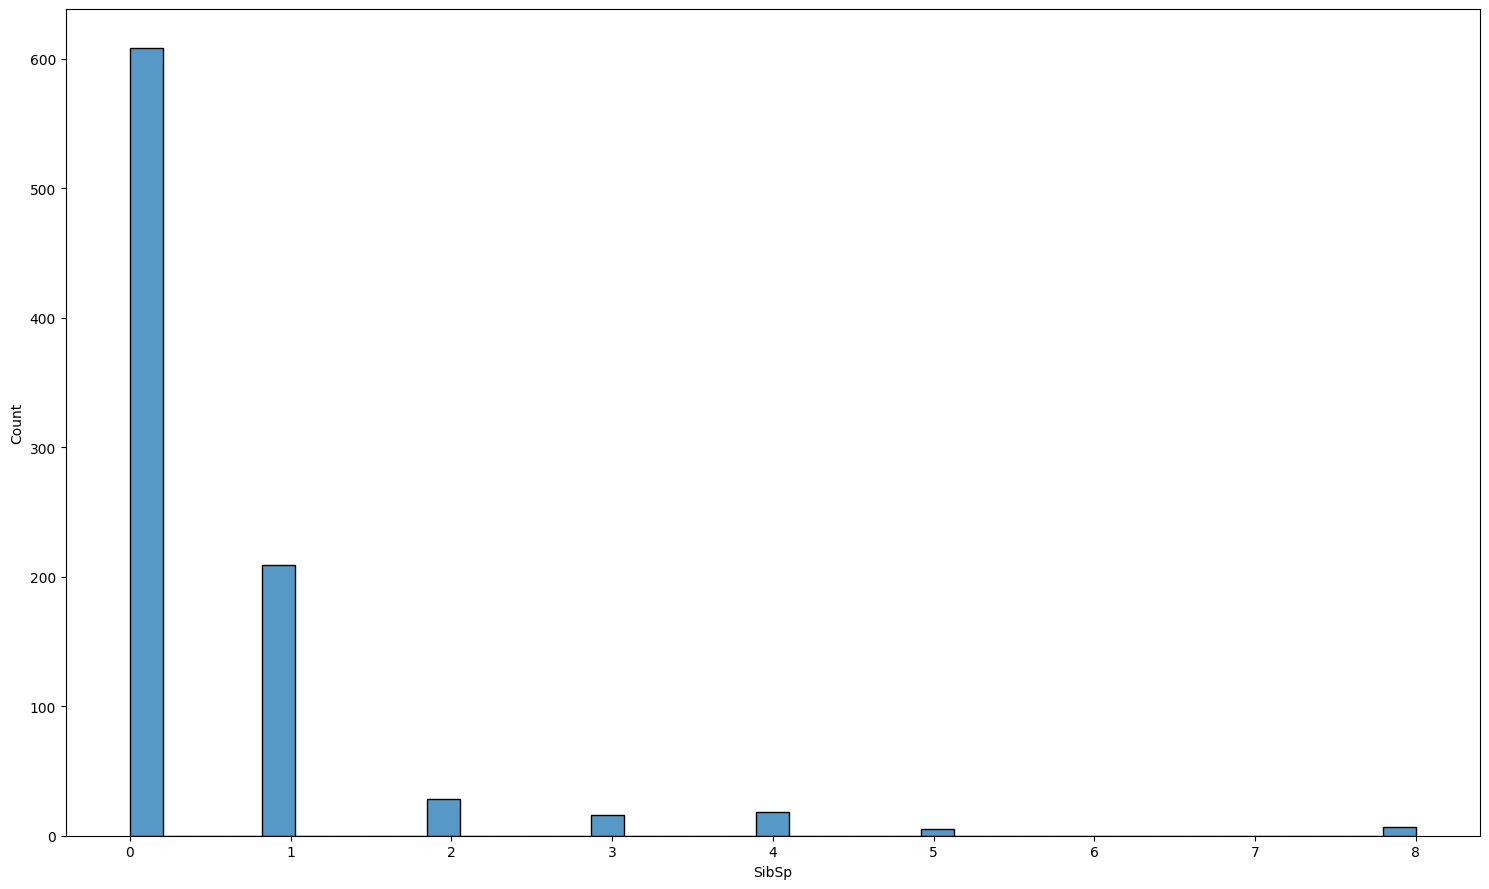

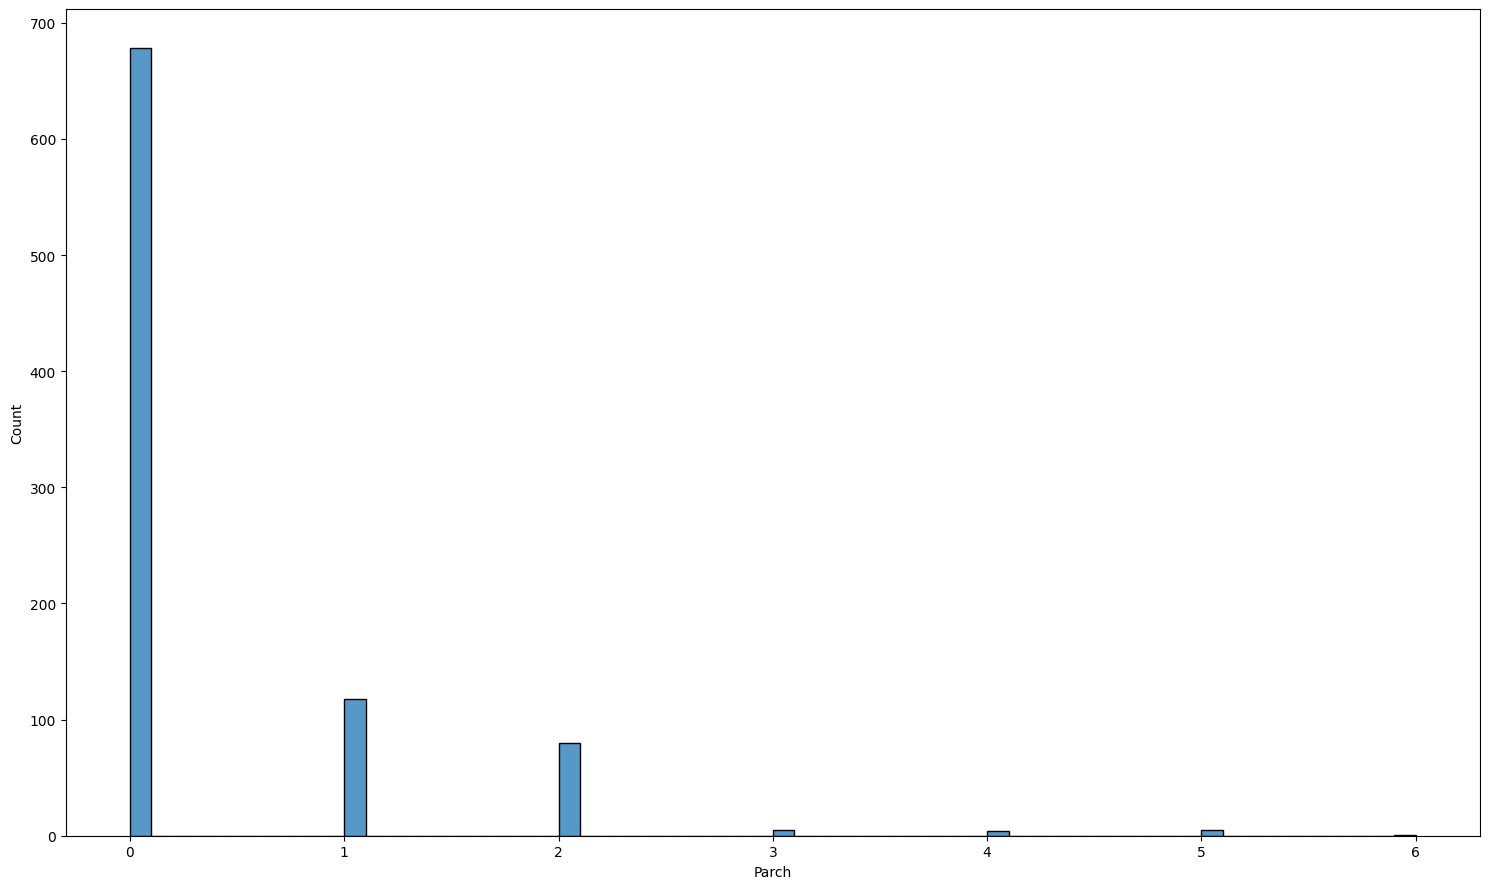

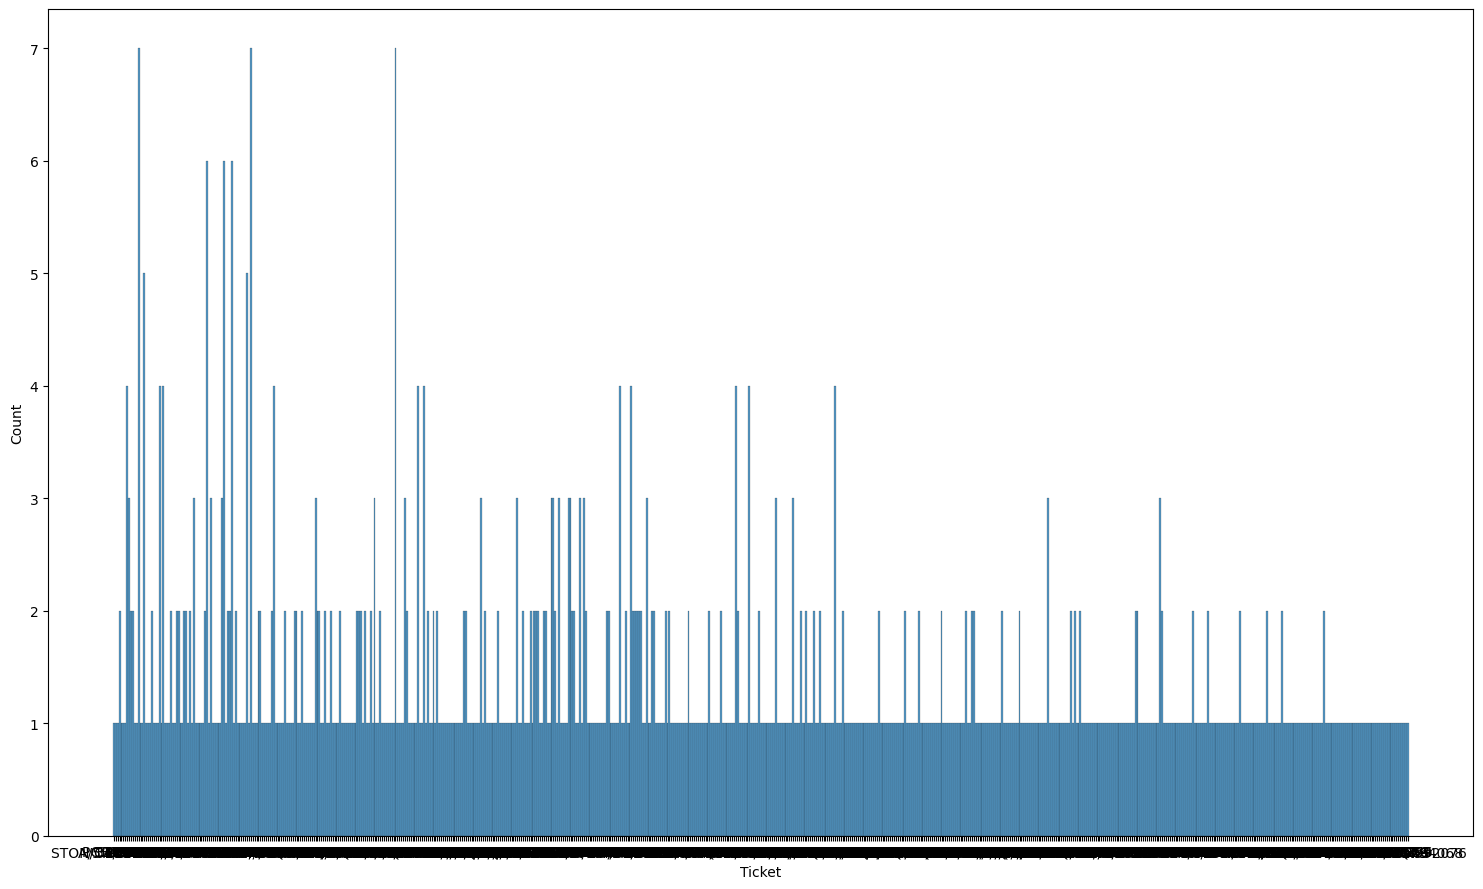

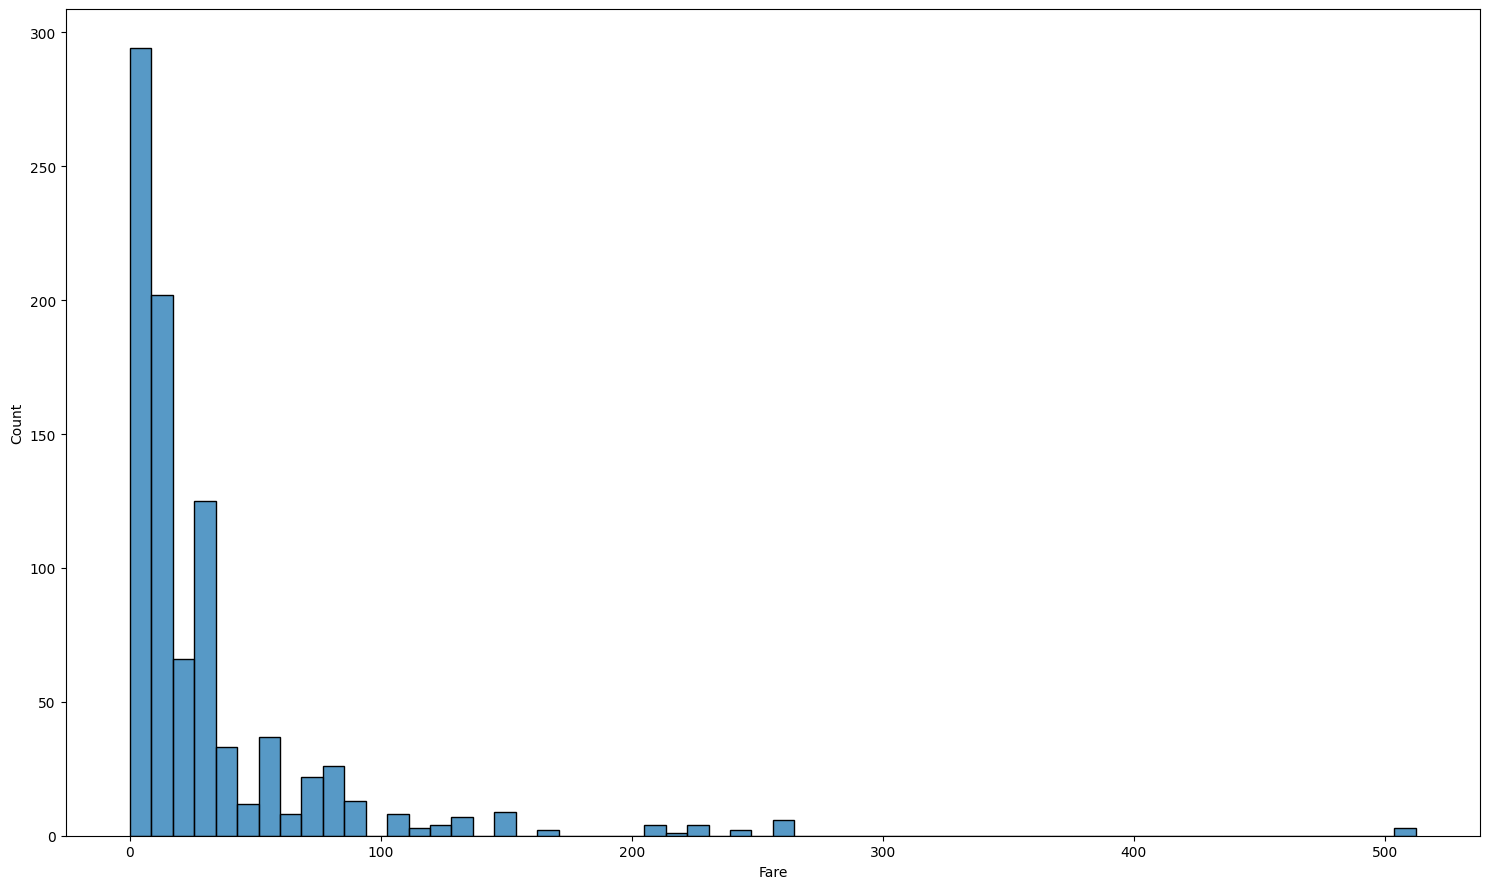

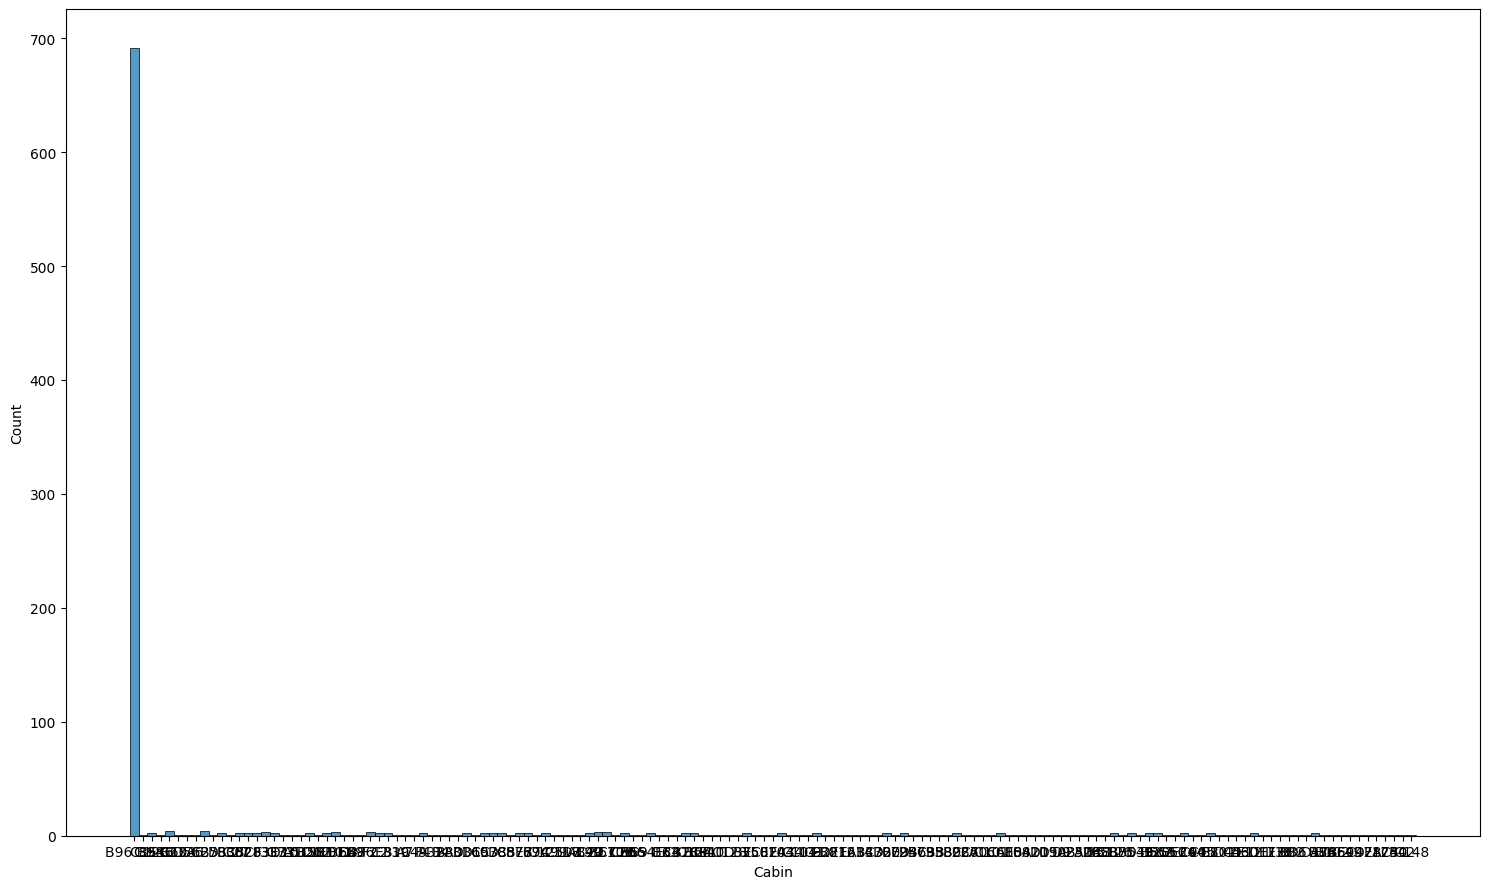

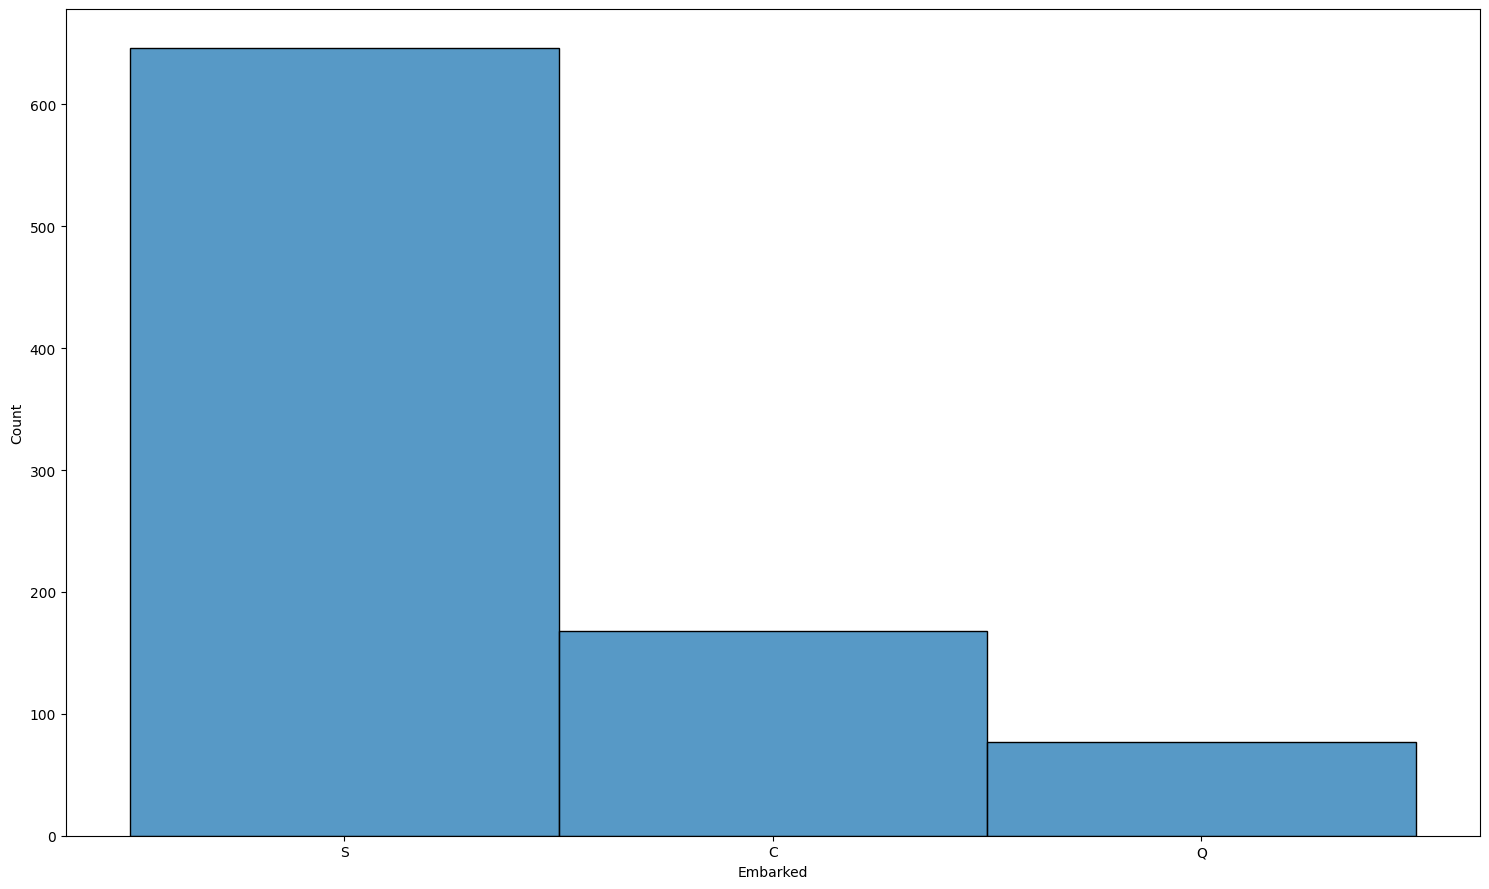

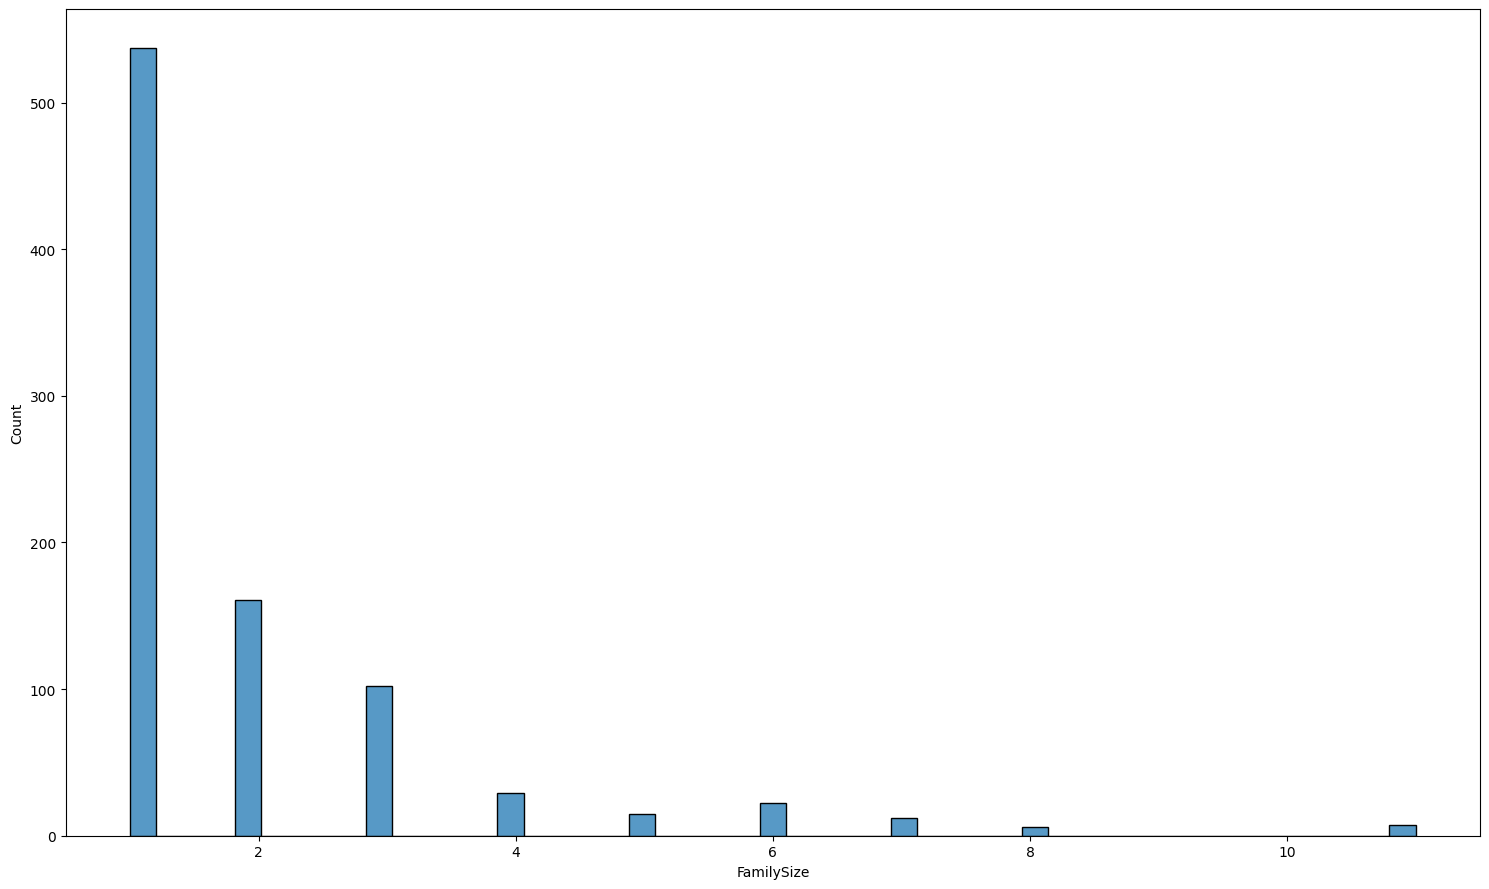

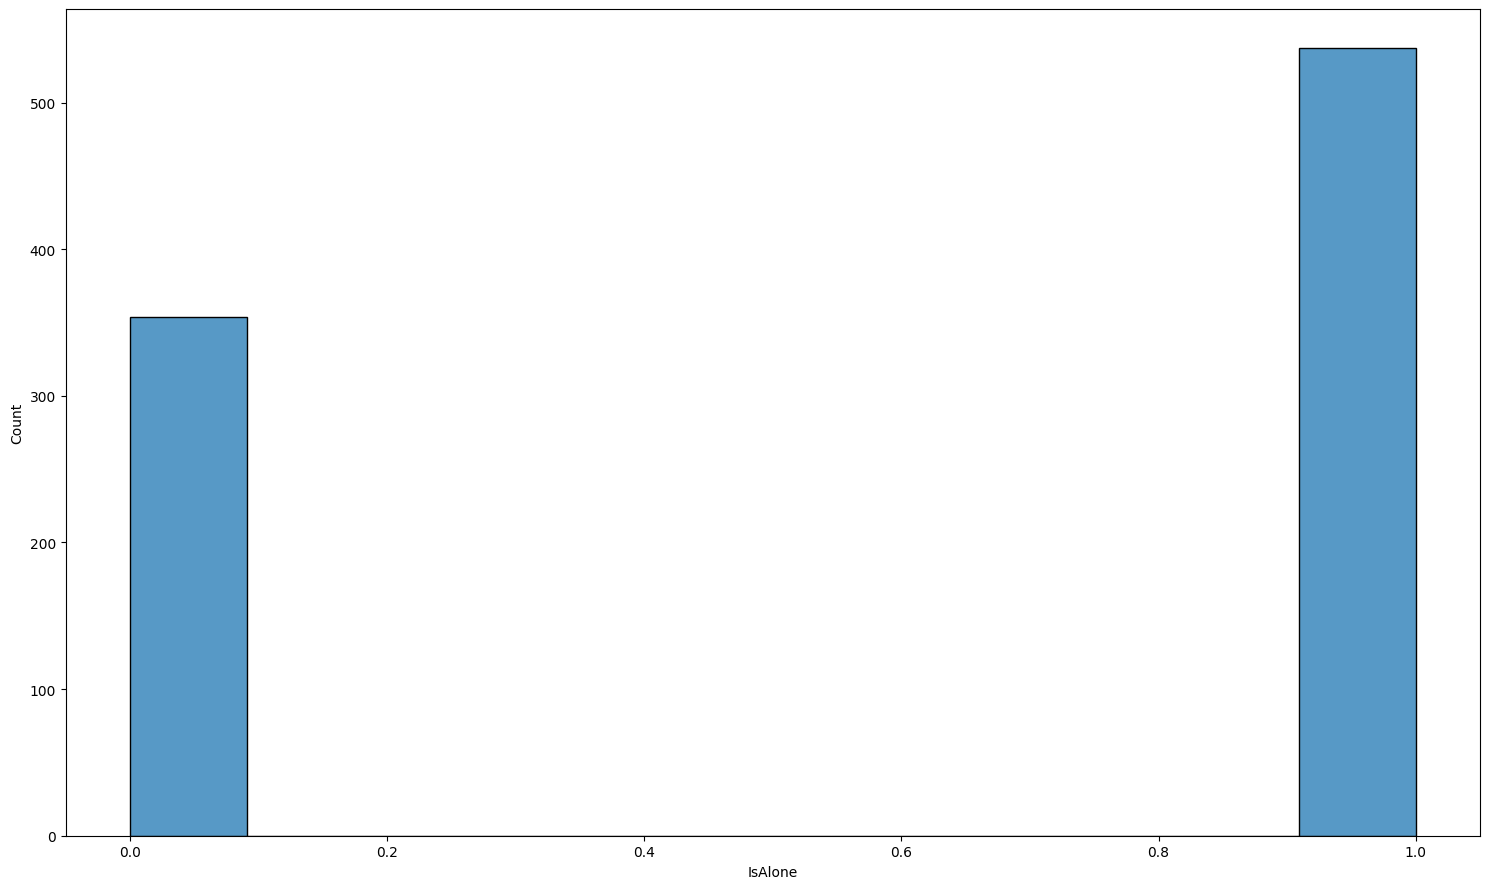

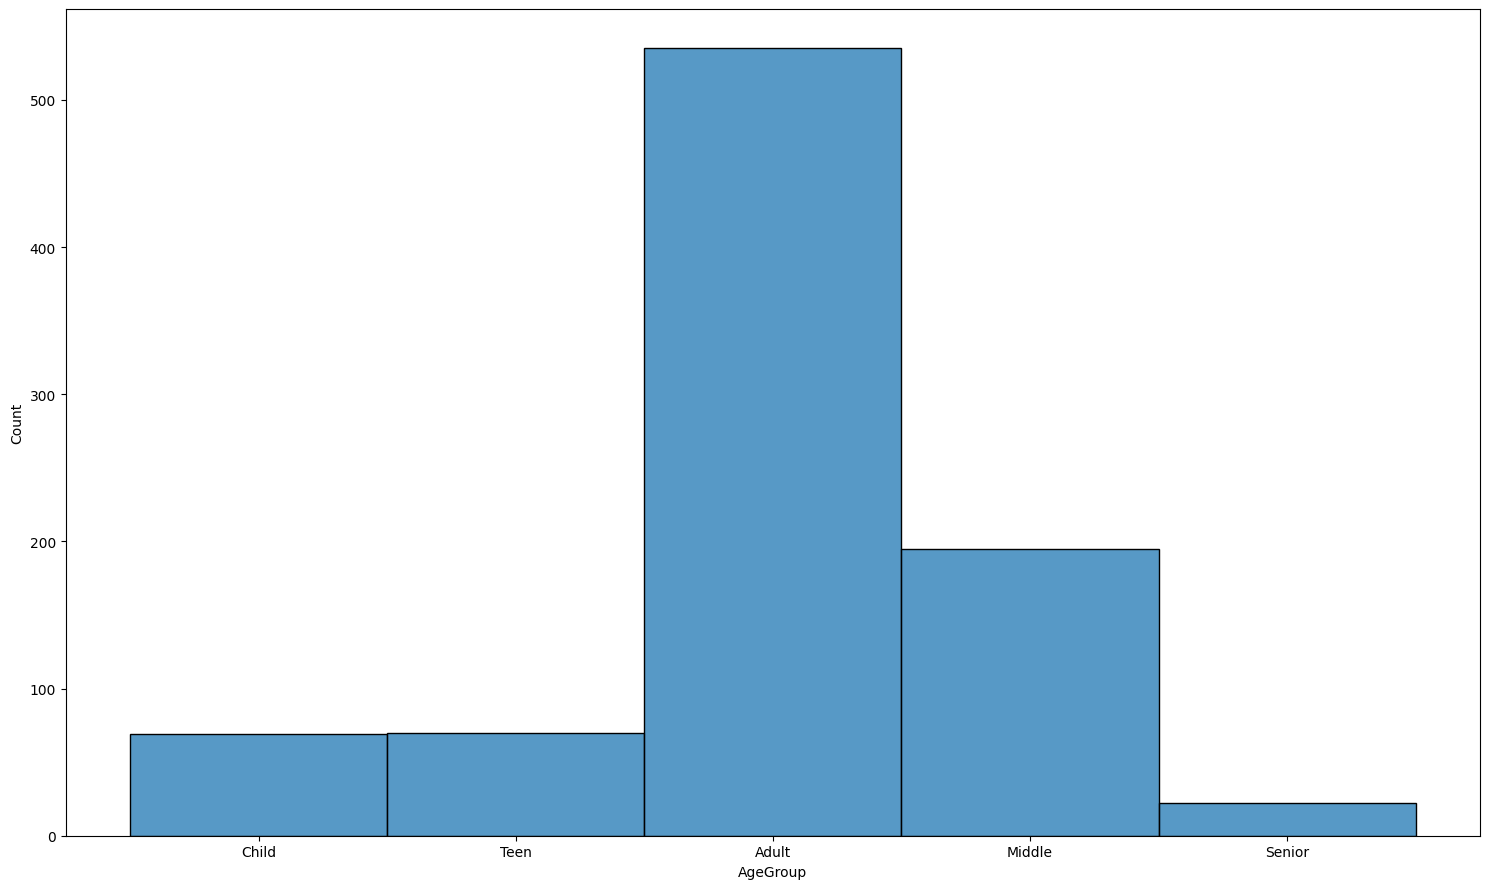

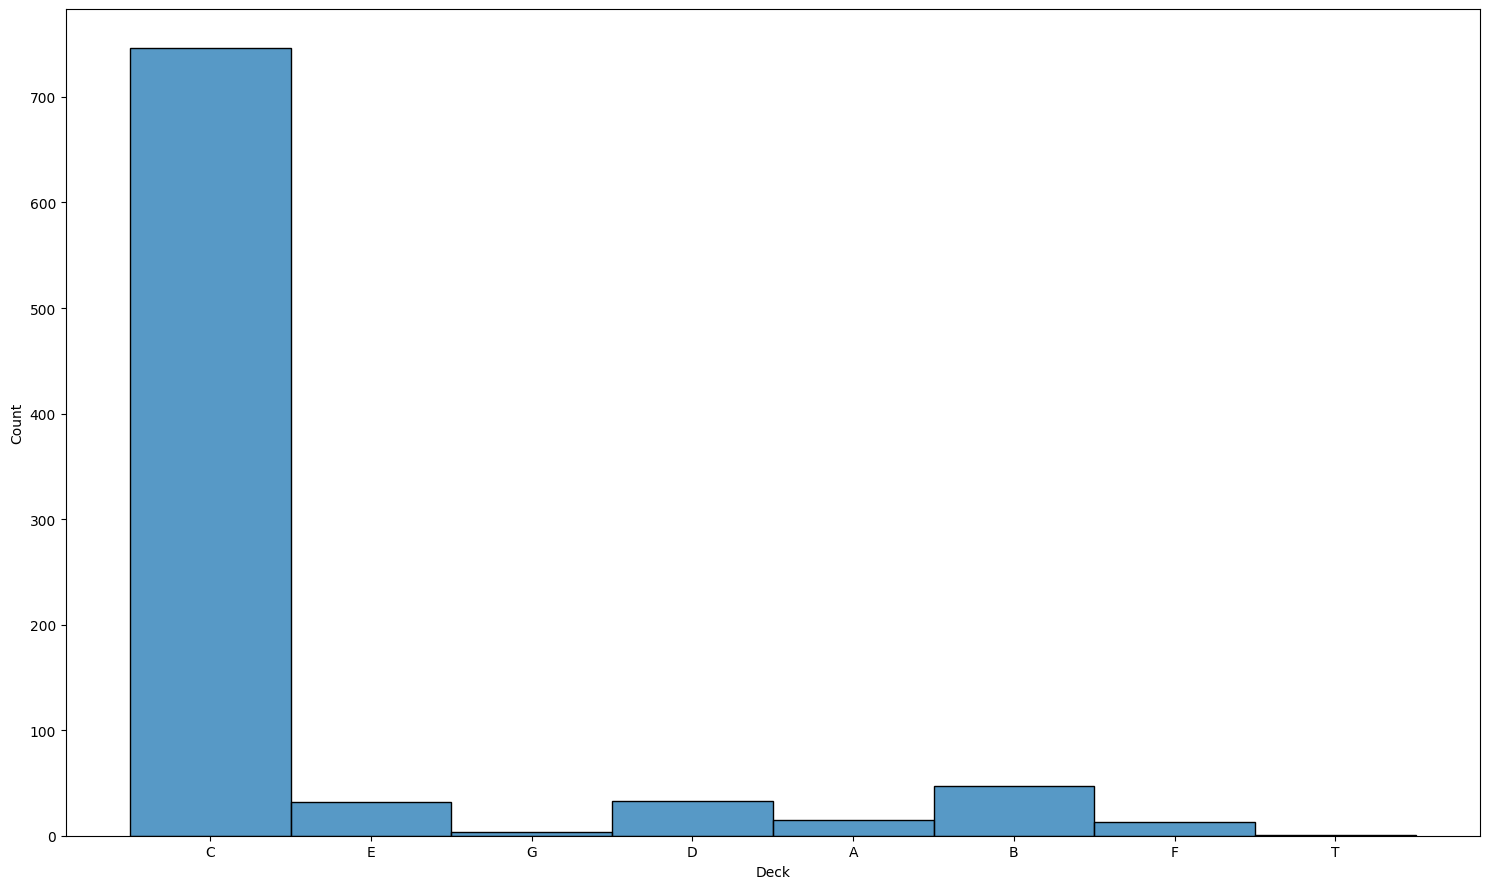

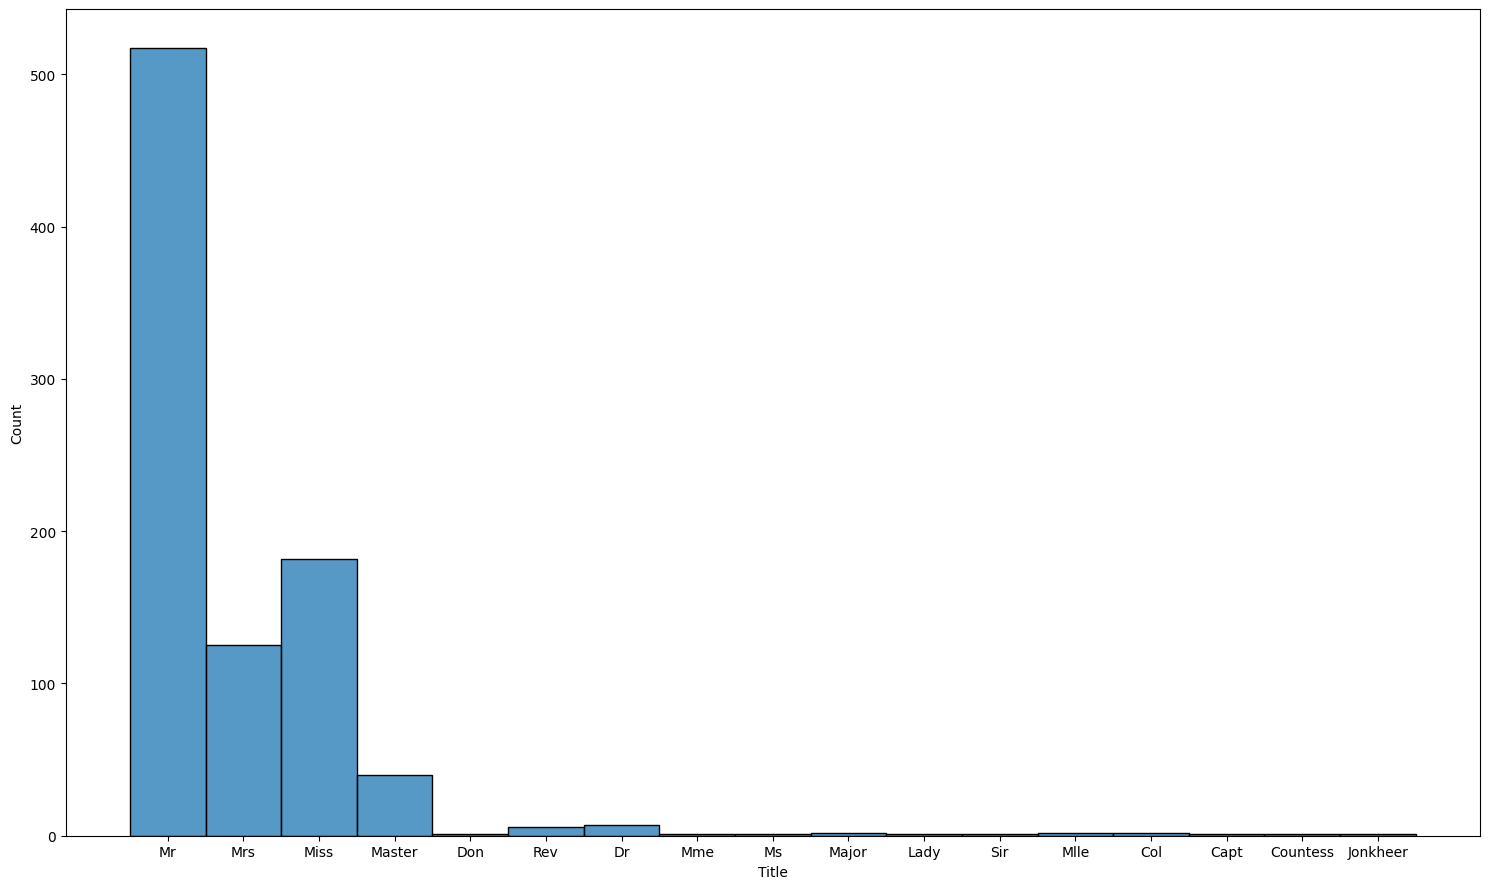

In [40]:
for col in df1.columns:
    plt.figure(
        figsize=(15, 9)
    )
    sns.histplot(
        data = df1,
        x = col
    )
    plt.tight_layout()
    plt.show()


In [41]:
df1.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'AgeGroup', 'Deck', 'Title'],
      dtype='object')

In [42]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup,Deck,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,2,0,Adult,C,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Middle,C,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1,1,Adult,C,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Adult,C,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,1,1,Adult,C,Mr


In [43]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

feature_columns = [
    'Pclass', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 
    'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'Deck', 'Title'
]

categorical_columns = ["Pclass", "Sex", "Ticket", "Cabin", "Embarked", "AgeGroup", "Deck", "Title"]
numeric_columns = ['SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
target_column = 'Survived'

X_train, X_test, y_train, y_test = train_test_split(
    df1[feature_columns],
    df1[target_column],
    test_size=0.3,
    random_state=42,
    stratify=df1[target_column]
)


preprocessor = ColumnTransformer(
    transformers=[
        ('cat_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns),
        ('num_scaler', StandardScaler(), numeric_columns)
    ],
    remainder='passthrough'
)


pipeline_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])


pipelines = {
    'RandomForest': pipeline_1,
    'LogisticRegression': pipeline_2,
    'SVM': pipeline_3
}

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'model': name,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"{name}:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("=" * 60)


print("\n📊 СРАВНЕНИЕ МОДЕЛЕЙ:")
print("Model            | Precision | Recall   | F1-Score |")
print("-" * 50)
for result in sorted(results, key=lambda x: x['f1'], reverse=True):
    print(f"{result['model']:15} | {result['precision']:8.4f} | {result['recall']:8.4f} | {result['f1']:8.4f} |")

RandomForest:
Precision: 0.8118
Recall:    0.6699
F1-Score:  0.7340

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.86       165
         1.0       0.81      0.67      0.73       103

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268

Confusion Matrix:
[[149  16]
 [ 34  69]]
LogisticRegression:
Precision: 0.7714
Recall:    0.7864
F1-Score:  0.7788

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       165
         1.0       0.77      0.79      0.78       103

    accuracy                           0.83       268
   macro avg       0.82      0.82      0.82       268
weighted avg       0.83      0.83      0.83       268

Confusion Matrix:
[[141  24]
 [ 22  81]]
SVM:
Precision: 0.7647
Recall:    0.7573
F1-Score:  0.7610

Classification

/Users/karlkorhonen/проекты/Data_analysis/Alfa_practice/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/karlkorhonen/проекты/Data_analysis/Alfa_practice/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/karlkorhonen/проекты/Data_analysis/Alfa_practice/venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
